In [1]:
import torch
import numpy as np

In [2]:
from torch.utils.data import DataLoader


In [3]:
t = torch.arange(6,dtype=torch.float32)

In [4]:
dataloader = DataLoader(t)

In [5]:
for item in dataloader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [6]:
dataloader = DataLoader(t,batch_size=3,drop_last=False)

In [7]:
for i,batch in enumerate(dataloader,1):
    print(f"batch {i}: {batch}")

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


In [8]:
torch.manual_seed(1)
t_x = torch.rand([4,3],dtype=torch.float32)
t_y = torch.arange(4)

In [9]:
from torch.utils.data import Dataset
class JointDataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [10]:
from torch.utils.data import TensorDataset
joint_dataset = TensorDataset(t_x,t_y)

In [11]:
for example in joint_dataset:
    print('x: ',example[0],'y: ',example[1])

x:  tensor([0.7576, 0.2793, 0.4031]) y:  tensor(0)
x:  tensor([0.7347, 0.0293, 0.7999]) y:  tensor(1)
x:  tensor([0.3971, 0.7544, 0.5695]) y:  tensor(2)
x:  tensor([0.4388, 0.6387, 0.5247]) y:  tensor(3)


In [12]:
jD = JointDataset(t_x,t_y)

In [13]:
for item in jD:
    print(item[0], item[1])

tensor([0.7576, 0.2793, 0.4031]) tensor(0)
tensor([0.7347, 0.0293, 0.7999]) tensor(1)
tensor([0.3971, 0.7544, 0.5695]) tensor(2)
tensor([0.4388, 0.6387, 0.5247]) tensor(3)


In [14]:
torch.manual_seed(1)

In [15]:
data_loader = DataLoader(dataset=joint_dataset,batch_size=2,shuffle=True)

In [16]:
for i, batch in enumerate(data_loader,1):
    print(f"batch {i}, x: {batch[0]}, y: {batch[1]}")

batch 1, x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]), y: tensor([2, 0])
batch 2, x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]), y: tensor([1, 3])


In [17]:
import pathlib
imgdir_path = pathlib.Path("cat_dog_images")
file_list = sorted([str(path_) for path_ in imgdir_path.glob("*.jpg")])

In [18]:
import torchvision.transforms as transforms

In [19]:
img_height, img_width = 80, 120
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height,img_width))
])

In [20]:
import os
from PIL import Image
class ImageDataset(Dataset):
    def __init__(self, file_list,labels,transform=None):
        self.file_list =file_list
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        img = Image.open(self.file_list[index])
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label
    
    def __len__(self):
        return len(self.labels)

In [21]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
image_dataset = ImageDataset(file_list,labels,transform)

In [22]:
from matplotlib import pyplot as plt 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.16920303..1.0000002].


ValueError: num must be an integer with 1 <= num <= 6, not 7

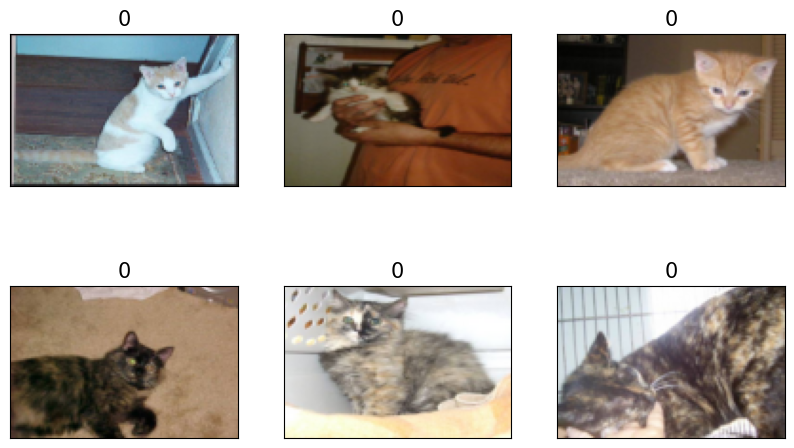

In [23]:
fig = plt.figure(figsize=(10,6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2,3,i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1,2,0)))
    ax.set_title(f"{example[1]}", size=15)

In [ ]:
import torchvision


In [ ]:
image_path = './'

In [ ]:
celeba_dataset = torchvision.datasets.CelebA(image_path, 
                                             split='train',target_type='attr',
                                             download=True)

RuntimeError: To download files from GDrive, 'gdown' is required. You can install it with 'pip install gdown'.